## Step 3: Zonal Market Prices 


## STEP 3C — Define Zones and ATC

### 3C.1 Choose zones ( We will use 2)
Zone A: buses 1–12

Zone B: buses 13–24

### 3C.2 Compute ATC between zones
For each pair of zones (a,b):

$$
ATC_{a,b} = \sum_{\ell \in \text{lines connecting }a\text{ and }b} F^{max}_\ell
$$

You can start with a manual ATC and later replace it with the computed one from branch data.


In [41]:
# Imports
import gurobipy as gp
from gurobipy import GRB
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


## Needed data from Step 1 (single hour)

In [42]:
# ---------- Step 1 data ----------
G = list(range(12))

P_max = {
    0: 152, 1: 152, 2: 350, 3: 591, 4: 60, 5: 155,
    6: 155, 7: 400, 8: 400, 9: 300, 10: 310, 11: 350
}

C = {
    0: 13.32, 1: 13.32, 2: 20.70, 3: 20.93, 4: 26.11,
    5: 10.52, 6: 10.52, 7: 6.02, 8: 5.47, 9: 0.00,
    10: 10.52, 11: 10.89
}

# Pick the hour you want to study (single hour)
D_total = 2650.5
U_bid = 100.0

# Wind availability for the selected hour
P_w_bar = 173.73  # MW


## 3C.1 Zone definition

Below is a simple 2-zone split:
- Zone A: buses 1–12
- Zone B: buses 13–24

In [43]:
# ---------- Zones ----------
ZONES = ["A", "B"]  # or ["A","B","C"] for three zones

# Bus-to-zone mapping
bus_zone = {b: ("A" if b <= 12 else "B") for b in range(1, 25)}

# Generator-to-bus mapping
gen_bus = {
    0: 1,  1: 2,  2: 7,  3: 13, 4: 15, 5: 15,
    6: 16, 7: 18, 8: 21, 9: 22, 10: 23, 11: 23
}


## 3C.2 Demand and wind allocation to zones

Allocate total demand and wind directly to zones.



In [44]:

#  50/50 split demand
demand_in_zone = {"A": 0.5 * D_total, "B": 0.5 * D_total}
bid_in_zone = {"A": U_bid, "B": U_bid}

#  all wind in zone A
wind_in_zone = {"A": P_w_bar, "B": 0.0}


## 3C.3 ATC between zones

In [45]:
# ---------- ATC (MW) ----------
# Base ATC between A and B
atc = {("A", "B"): 500.0}  # MW


In [46]:
def compute_atc(lines, bus_zone):
    """Compute ATC between zones by summing capacities of lines that cross zones.

    lines: list of dicts like {"from": int, "to": int, "Fmax": float}
    bus_zone: dict bus -> zone
    """
    atc = {}
    for l in lines:
        za = bus_zone[l["from"]]
        zb = bus_zone[l["to"]]
        if za == zb:
            continue
        key = tuple(sorted((za, zb)))
        atc[key] = atc.get(key, 0.0) + float(l["Fmax"])
    return atc


## Build the zonal model

### Variables
- p[i] : generation of generator i
- pw[z] : wind in zone z
- d[z] : demand served in zone z
- f[a,b] : exchange flow (positive a→b), bounded by ATC

### Zonal balance (for each zone z)
$$
\sum_{g\in z} p_g + p^{wind}_z + \text{netImport}_z = d_z
$$




In [47]:
def solve_zonal_market(
    ZONES, atc, G, C, P_max, gen_bus, bus_zone,
    demand_in_zone, bid_in_zone, wind_in_zone,
    atc_scale=1.0, verbose=False
):
    m = gp.Model("ZonalMarket")
    m.Params.OutputFlag = 1 if verbose else 0

    # Generation
    p = m.addVars(G, lb=0.0, ub={i: P_max[i] for i in G}, name="p")

    # Zonal wind + demand
    pw = m.addVars(ZONES, lb=0.0, ub=wind_in_zone, name="pw")
    d  = m.addVars(ZONES, lb=0.0, ub=demand_in_zone, name="d")

    # Inter-zonal flows
    flow = {}
    for (a, b), cap in atc.items():
        cap_eff = atc_scale * float(cap)
        flow[(a, b)] = m.addVar(lb=-cap_eff, ub=cap_eff, name=f"f_{a}_{b}")

    # Objective: minimize cost - utility (equiv. maximize welfare)
    m.setObjective(
        gp.quicksum(C[i] * p[i] for i in G) - gp.quicksum(bid_in_zone[z] * d[z] for z in ZONES),
        GRB.MINIMIZE
    )

    # Zonal balances (store to read duals)
    balance = {}
    for z in ZONES:
        gen_in_z = gp.quicksum(p[i] for i in G if bus_zone[gen_bus[i]] == z)

        net_import = 0
        for (a, b), fvar in flow.items():
            # Convention: f_(a,b) > 0 means a exports to b
            if z == a:
                net_import += -fvar
            elif z == b:
                net_import += fvar

        balance[z] = m.addConstr(gen_in_z + pw[z] + net_import == d[z], name=f"bal_{z}")

    m.optimize()

    prices = {z: balance[z].Pi for z in ZONES}
    flow_val = {k: v.X for k, v in flow.items()}

    total_cost = sum(C[i] * p[i].X for i in G)
    total_utility = sum(bid_in_zone[z] * d[z].X for z in ZONES)
    welfare = total_utility - total_cost

    return {
        "model": m,
        "prices": prices,
        "flow_val": flow_val,
        "total_cost": total_cost,
        "welfare": welfare,
        "p": p, "pw": pw, "d": d
    }


## Run zonal model once (single ATC)

In [48]:
res = solve_zonal_market(
    ZONES=ZONES, atc=atc, G=G, C=C, P_max=P_max,
    gen_bus=gen_bus, bus_zone=bus_zone,
    demand_in_zone=demand_in_zone, bid_in_zone=bid_in_zone,
    wind_in_zone=wind_in_zone,
    atc_scale=1.0, verbose=False
)

print("Zonal prices (€/MWh):", res["prices"])
print("Interzonal flows (MW):", res["flow_val"])
print(f"Total cost (€): {res['total_cost']:.2f}")
print(f"Social welfare (€): {res['welfare']:.2f}")


Zonal prices (€/MWh): {'A': 20.7, 'B': 10.89}
Interzonal flows (MW): {('A', 'B'): -500.0}
Total cost (€): 23507.52
Social welfare (€): 241542.48


## Sensitivity: different ATC values 

So we vary ATC by a multiplier and observe:
- price separation for low ATC (congestion)
- price convergence for high ATC (copper-plate limit)

In [49]:
scales = [0.0, 0.1, 0.25, 0.5, 1.0, 2.0, 10.0]

rows = []
for s in scales:
    out = solve_zonal_market(
        ZONES=ZONES, atc=atc, G=G, C=C, P_max=P_max,
        gen_bus=gen_bus, bus_zone=bus_zone,
        demand_in_zone=demand_in_zone, bid_in_zone=bid_in_zone,
        wind_in_zone=wind_in_zone,
        atc_scale=s, verbose=False
    )
    row = {"ATC_scale": s, "Welfare": out["welfare"], "Cost": out["total_cost"]}
    for z in ZONES:
        row[f"lambda_{z}"] = out["prices"][z]
    for (a,b), v in out["flow_val"].items():
        row[f"flow_{a}_{b}"] = v
    rows.append(row)

df = pd.DataFrame(rows)
df


,ATC_scale,Welfare,Cost,lambda_A,lambda_B,flow_A_B
0,0.00,197038.0900,18259.9100,100.0,10.52,-0.00
1,0.10,201512.0900,18785.9100,100.0,10.52,-50.00
2,0.25,208223.0900,19574.9100,100.0,10.52,-125.00
3,0.50,219408.0900,20889.9100,100.0,10.52,-250.00
4,1.00,241542.4835,23507.5165,20.7,10.89,-500.00
5,2.00,243943.4810,21106.5190,20.7,20.70,-744.75
6,10.00,243943.4810,21106.5190,20.7,20.70,-744.75


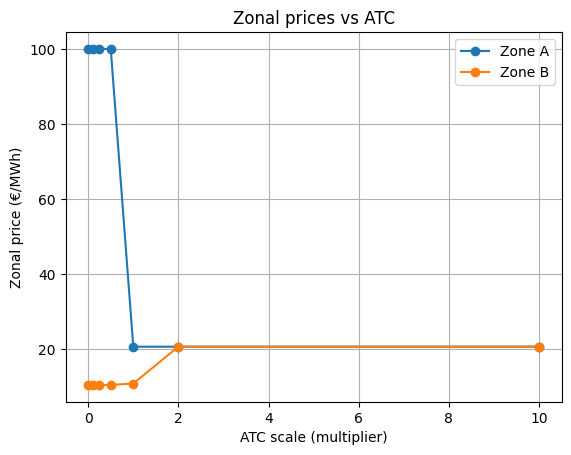

In [50]:
plt.figure()
for z in ZONES:
    plt.plot(df["ATC_scale"], df[f"lambda_{z}"], marker="o", label=f"Zone {z}")
plt.xlabel("ATC scale (multiplier)")
plt.ylabel("Zonal price (€/MWh)")
plt.title("Zonal prices vs ATC")
plt.grid(True)
plt.legend()
plt.show()


## Compare with nodal prices



In [51]:
import numpy as np

# --- 1) Define zone split (same as zonal model)
bus_zone = {b: ("A" if b <= 12 else "B") for b in range(1, 25)}

# --- 2) Paste nodal prices from nodal notebook
lambda_nodal = {b: 20.70 for b in range(1, 25)}  # replace if needed

# --- 3) Compute average nodal price per zone
def zonal_average_from_nodal(lambda_nodal, bus_zone):
    zones = sorted(set(bus_zone.values()))
    zavg = {}
    for z in zones:
        buses = [b for b, zz in bus_zone.items() if zz == z]
        zavg[z] = float(np.mean([lambda_nodal[b] for b in buses]))
    return zavg

zavg = zonal_average_from_nodal(lambda_nodal, bus_zone)

print("Average nodal price per zone:", zavg)
print("Zonal market prices:", res["prices"])

Average nodal price per zone: {'A': 20.699999999999996, 'B': 20.699999999999996}
Zonal market prices: {'A': 20.7, 'B': 10.89}


In [52]:

#In the nodal model, the transmission lines are not overloaded,so all nodal prices are the same and amount to 20.70 €/MWh.

#In the two-zone zonal model (buses 1-12 and 13-24), price unbundling occurs when the available throughput (ATC) between zones is limited.
#This difference arises because the ATC restriction becomes mandatory, creating inter-zonal congestion. xport zone.As a result, prices are higher in the import zone and lower in the e

### Conclusion

- Nodal prices are uniform (20.70 €/MWh) because there is no line congestion.
- Zonal prices differ when ATC is binding.
- Lower ATC → larger price separation.
- High ATC → zonal prices converge to the nodal price.